In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
class AdalineGD:
    def __init__(self, learning_rate=0.0003, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        rgen = np.random.RandomState(420)
        self.weights = rgen.normal(loc=0.0, scale=0.01, size=n_features)
        self.bias = 0.0
        for afsadfds in range(self.epochs):
            net_input = np.dot(X, self.weights) + self.bias
            errors = y - net_input

            self.weights += self.lr * np.dot(X.T, errors)
            self.bias += self.lr * errors.sum()

            cost = (errors**2).sum() / 2.0
            self.cost_history.append(cost)

    def predict(self, X):
        net_input = np.dot(X, self.weights) + self.bias
        return np.where(net_input >= 0.0, 1, -1)



In [ ]:
class AdalineSGD:
    def __init__(self, learning_rate=0.0003, epochs=50, random_state=420):
        self.lr = learning_rate
        self.epochs = epochs
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        rgen = np.random.RandomState(self.random_state)
        self.weights = rgen.normal(loc=0.0, scale=0.01, size=n_features)
        self.bias = 0.0
        for afsadfds in range(self.epochs):
            X_shuffled, y_shuffled = self._shuffle(X, y, rgen)
            cost_epoch = 0

            for x_i, y_i in zip(X_shuffled, y_shuffled):
                net_input = np.dot(x_i, self.weights) + self.bias
                error = y_i - net_input

                self.weights += self.lr * error * x_i
                self.bias += self.lr * error

                cost_epoch += 0.5 * (error**2)
            # Trung bình Loss trong 1 epoch
            self.cost_history.append(cost_epoch / n_samples)


    def _shuffle(self, X, y, rgen):
        p = rgen.permutation(len(y))
        return X[p], y[p]
    def predict(self, X):
        net_input = np.dot(X, self.weights) + self.bias
        return np.where(net_input >= 0.0, 1, -1)



In [ ]:
# prepare data
data = load_breast_cancer()
X, y = data.data, data.target
y = np.where(y == 0, -1, 1)  # encode 0-> -1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=420, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# train and measure
bgd = AdalineGD(learning_rate=0.0003, epochs=50)
start_bgd = time.time()
bgd.fit(X_train, y_train)
time_bgd = time.time() - start_bgd

acc_bgd_train = np.mean(bgd.predict(X_train) == y_train) * 100
acc_bgd_test = np.mean(bgd.predict(X_test) == y_test) * 100

sgd = AdalineSGD(learning_rate=0.0003, epochs=50)
start_sgd = time.time()
sgd.fit(X_train, y_train)
time_sgd = time.time() - start_sgd

acc_sgd_train = np.mean(sgd.predict(X_train) == y_train) * 100
acc_sgd_test = np.mean(sgd.predict(X_test) == y_test) * 100

In [ ]:
print(f"{'Tiêu chí':<25} | {'Adaline BGD':<15} | {'Adaline SGD':<15}")
print("-" * 61)
print(f"{'Thời gian train (s)':<25} | {time_bgd:<15.5f} | {time_sgd:<15.5f}")
print(f"{'Accuracy Tập Train (%)':<25} | {acc_bgd_train:<15.2f} | {acc_sgd_train:<15.2f}")
print(f"{'Accuracy Tập Test (%)':<25} | {acc_bgd_test:<15.2f} | {acc_sgd_test:<15.2f}")

Tiêu chí                  | Adaline BGD     | Adaline SGD    
-------------------------------------------------------------
Thời gian train (s)       | 0.00143         | 0.07464        
Accuracy Tập Train (%)    | 97.36           | 97.36          
Accuracy Tập Test (%)     | 90.35           | 90.35          


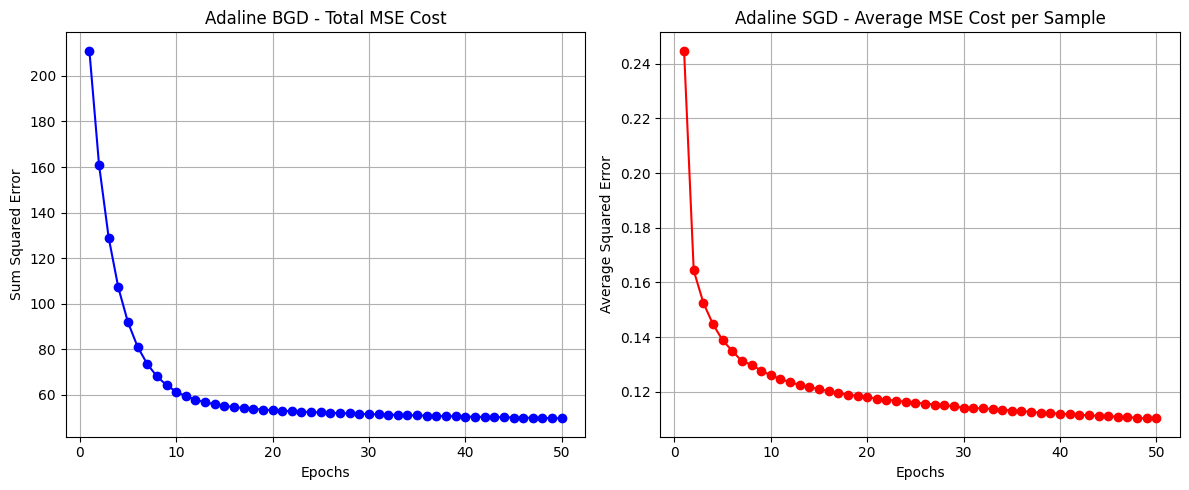

In [ ]:
# ------------------------------------------
# Vẽ biểu đồ So sánh tốc độ hội tụ (Loss Curve)
# ------------------------------------------
plt.figure(figsize=(12, 5))

# Đồ thị BGD
plt.subplot(1, 2, 1)
plt.plot(range(1, len(bgd.cost_history) + 1), bgd.cost_history, marker='o', color='blue')
plt.title('Adaline BGD - Total MSE Cost')
plt.xlabel('Epochs')
plt.ylabel('Sum Squared Error')
plt.grid(True)

# Đồ thị SGD
plt.subplot(1, 2, 2)
plt.plot(range(1, len(sgd.cost_history) + 1), sgd.cost_history, marker='o', color='red')
plt.title('Adaline SGD - Average MSE Cost per Sample')
plt.xlabel('Epochs')
plt.ylabel('Average Squared Error')
plt.grid(True)

plt.tight_layout()
plt.show()